# Лабораторная работа 4. ООП. Классы. Регрессия с помощью гауссовских процессов

✨ **В чем суть?** ✨



 Есть некоторая статья далекого 1995 года про гауссовские процессы: https://proceedings.neurips.cc/paper_files/paper/1995/file/7cce53cf90577442771720a370c3c723-Paper.pdf

В этой статье описывается, как можно решать задачу регрессии (задачу поиска функции $f$ по заданным $x, y$, так чтобы выполнялось $f(x) ≃ y$ как можно более точно) с помощью гауссовских процессов.

Мы хотим реализовать алгоритм, описанный в этой статье.

# Преамбула

**Нормальное распределение**:


 Оно отвечает на вопрос: "Если я измерю рост случайного человека, какой рост я, скорее всего, получу?"

- Средний рост - 170 см

- Большинство людей - около среднего

- Очень высоких и очень низких - мало

Мы можем сказать: "С вероятностью 95% рост будет между 150 и 190 см".


Вот примерно такое распределение данных и описывает нормальное распределение. Давайте посмотрим на график:

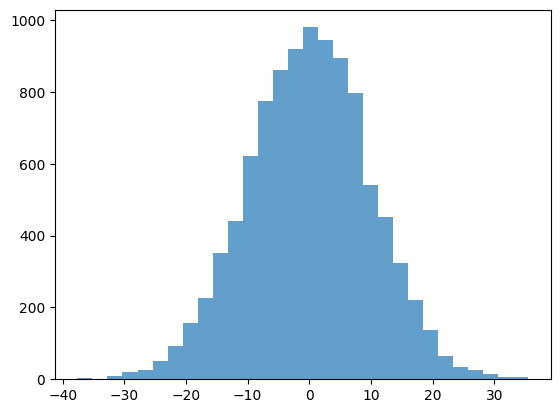

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


data = np.random.normal(0, 10, 10000) # генерим кучу точек из нормального распределения

plt.hist(data, bins=30, alpha=0.7)
plt.show()

**Определения:**


Пусть $(\Omega, \mathcal{F}, P)$ — вероятностное пространство, где:

$\Omega$ — пространство элементарных исходов

$\mathcal{F}$ — σ-алгебра событий

$P$ — вероятностная мера



**Определение 1.** Случайная величина $X$ — это измеримая функция $X: \Omega \rightarrow \mathbb{R}$


**Определение 2.** Гауссовский процесс (ГП) — это последовательность случайных величин, любое конечное подмножество которых имеет совместное многомерное нормальное распределение (то есть каждая компонента $X_i$ полученного случайного вектора  $\mathbf{X} = (X_1, X_2, \ldots, X_n)^T$ имеет нормальное распределение)

Из [нашей статьи](https://proceedings.neurips.cc/paper_files/paper/1995/file/7cce53cf90577442771720a370c3c723-Paper.pdf) можно узнать, что



> A Gaussian process is a stochastic process which can be fully specified by its mean function $\mu(x) = \mathbb{E}[Y(x)]$ and its covariance function $C(x, x') = \mathbb{E}[(Y(x) - \mu(x))(Y(x') - \mu(x'))]$.



То есть для задания  гауссовского процесса ${Y(x)}$ нам достаточно задать две функции:

- Функцию среднего: $μ(x) = E[Y(x)]$

- Ковариационную функцию (ядро): $C(x, x') = E[(Y(x)-μ(x))(Y(x')-μ(x'))]$

Далее, автор нам говорит, что:
>  Below we consider Gaussian processes which have  $μ(x) = 0$

 Таким образом, для того чтобы задать этот самый гауссовский процесс, нам всего лишь нужно каким-то образом выбрать функцию ядра.



**Ядра:**

бывают, вообще говоря, разными. Вот несколько примеров, как может задаваться функция ядра:

Здесь `x` - это вектор из $\mathbb{R^d}$

| Ядро |Формула  | Параметры |
|:----:|:----------------------------------------------------------------------------------------------------------------|:---------:|
| **RBF** | $$k(\mathbf{x}, \mathbf{x}') = \exp\left(-\gamma \|\mathbf{x} - \mathbf{x}'\|^2\right)$$ | $$\gamma > 0$$ |
| **Linear** | $$k(\mathbf{x}, \mathbf{x}') = \mathbf{x}^T\mathbf{x}'$$ | — |
| **White Noise** | $$k(\mathbf{x}, \mathbf{x}') = \sigma^2 \ \text{if} \ \mathbf{x} == \mathbf{x}' \ \text{else} \ 0$$ | $\sigma^2 > 0$ |
| **Rational Quadratic** | $$k(\mathbf{x}, \mathbf{x}') = \left(1 + \dfrac{\|\mathbf{x} - \mathbf{x}'\|^2}{2\alpha l^2}\right)^{-\alpha}$$ | $\alpha > 0$, $l > 0$ |
| **Polynomial** | $$k(\mathbf{x}, \mathbf{x}') = (\sigma^2 + \gamma \cdot \mathbf{x}^T\mathbf{x}')^d$$ | $\sigma^2 \geq 0$, $\gamma > 0$, $d \in \mathbb{N}$ |

# Задание 1 (5 баллов)


## Задание 1.1

Создайте абстрактный базовый класс `Kernel`. Он будет задавать интерфейс для всех ядер.

**Что должен поддерживать:**

- Метод `__call__`  — должен принимать на вход два набора точек и возвращать матрицу попарных значений ядра между ними;
- Метод `get_params` - получить параметры ядра;

- Метод `set_params` - установить параметры ядра;

- Складываться с другим ядром;

- Умножаться на другое ядро;

❗**Подумайте, какие методы должны быть абстрактными, а какие нет**.

In [ ]:
# My fantastic code

## Задание 1.2


**Вопрос:**

А какой объект, собственно, будет выдавать метод сложения/умножения двух ядер?

Напишите **композитное ядро** - наследник `Kernel`, который будет поддерживать сложные операции с ядрами. У него должен быть magic метод `__repr__()` для удобного представления композиции ядер.


Подумайте, как его реализовать так, чтобы можно было работать, к примеру, со следующим объектом: `RBF()*White Noise() + Linear()`.  


In [ ]:
# My fantastic code

## Задание 1.3

Классы, задающие ядра

1. `RBF`
2. `Linear`
3. `WhiteNoise`
4. `RationalQuadratic`
5. `Polynomial`

In [ ]:
# My fantastic code

Код для самопроверки, ничего не доджно падать:



```
X = np.array([[1, 2], [3, 4], [5, 6]])
Y = np.array([[1, 2], [7, 8]])

rbf = RBF(gamma=1.0)           
linear = Linear()               
noise = WhiteNoise(0.1)         

kernel1 = rbf + linear          
kernel2 = rbf * linear         
kernel3 = rbf + linear * noise

kernel1(X, Y)
kernel2(X, Y)
kernel3(X, Y)
```



## Задание 1.4

Для упрощения жизни

Создайте класс `KernelFactory`, который будет иметь всего один метод `create(kernel_name, **params)`, возвращающий соответствующее ядро по его строковому имени.




P.S. Теперь вместо


```
kernel1 = RBF()
kernel2 = Linear()
kernel3 = WhiteNoise(0.1)
```

Мы будем писать

```
kernel1 = KernelFactory("rbf")
kernel2 = KernelFactory("linear")
kernel3 = KernelFactory("whitenoise")
```
И!

Вишенка на торте! 🍒

Можно удобно итерироваться по ядрам:

```
for name in ["rbf", "linear", "whitenoise"]:
  kernel = KernelFactory(name)
```


P.P.S. Мы придумали паттерн программирования "Фабрика".

Давайте это закодим:

In [ ]:
# My fantastic code

# Задание 2 (3 балла)

Теперь нужно написать класс регрессора. В машинном обучении традиционно есть две функции:

1. `fit(x, y)` - функция обучения, в которой мы выполняем какие-то подготовительные операции и вычисляем все, что нам нужно, **на тренировочных данных**.

Здесь мы учимся понимать, какая должна быть функция `f`, чтобы `f(x) = y`

2. `predict(x)` - здесь мы получаем уже **тестовые данные** `x`, для которых нужно дать ответ `f(x) = y`.

### `GaussianProcessRegressor`



Создайте класс `GaussianProcessRegressor`, который реализует регрессию с помощью гауссовских процессов.



**Что принимает при создании:**

    - `kernel` — объект ядра (наследник класса `Kernel`)

    - `noise_level` — уровень шума в данных (число, по умолчанию 0.1)



Какие у класса будут методы?

#### `fit(X_train, y_train)`
```
Обучение регрессора.

Parameters
----------
X_train : np.ndarray, shape (n_samples, n_features)
    Обучающие данные
y_train : np.ndarray, shape (n_samples,)
    Целевые значения
```



**Что принимает?**


> The training data consists of n pairs of inputs and targets ${(x^{(i)}, t^{i}), i = 1 ... n}$. The input vector for a test case is denoted $x$ (with no superscript). The inputs are d-dimensional $x_1, ..., x_d$ and the targets are scalar.

**Что делает?**

Посмотрим на этот кусок, где описывается, как мы будем выдавать предсказание $(1)$ (в функции `predict`). Нам нужно понять, как вычислить необходимые параметры. А именно, матрицу $K^{-1}t$

> In general, the predictive distribution is Gaussian with mean and variance:
>
> $\hat{y}^k(x) = k^T(x)K^{-1}t \qquad (1)$
>
> $\sigma^2_{\hat{y}}(x) = C(x,x) - k^T(x)K^{-1}k(x)\qquad (2)$
>
>
> where $k(x) = (C(x, x^{(1)}), ... , C(x, x^{(n)}))^T,  \ K$ is the covariance matrix for the
training cases $K_{ij} = C(x^{(i)}, x^{(j)})$, and $t = (t^{(1)}, ... , t^{(n)})^T$ .






Ковариационная функция в статье предлагается следующая:
$C(x^{(i)}, x^{(j)}) = v_0 \exp\left\{-\frac{1}{2} \sum_{l=1}^d w_l (x_l^{(i)} - x_l^{(j)})^2\right\} + a_0 + a_1 \sum_{l=1}^d x_l^{(i)} x_l^{(j)} + v_1 \delta(i, j)$


Но поскольку мы с вами реализовали разные ядра, давайте посмотрим, как они справятся с нашей задачей. Ключевая идея здесь - добавить небольшой шум на диагональ матрицы:

$C(x, x) + v_1 I$


Для того чтобы вычислить эти параметры нам понадобится обратная матрица. Тут есть загвоздка - обратную матрицу никто не вычисляет, потому что это дорогая операция. Вместо того чтобы вычислять $K^{-1}\mathbf{t}$, решают СЛАУ $K\alpha = \mathbf{t}$

Поскольку матрица у нас симметричная положительно определенная, то будем решать СЛАУ с помощью разложения Холецкого:

Вместо $K^{-1}\mathbf{t}$ мы:

0. Раскладываем $K = LL^T$ (Холецкий)

1. Решаем $L \mathbf{y} = \mathbf{t}$

2. Решаем $L^T \alpha = \mathbf{y}$

Нигде не вычисляем $K^{-1}$ явно, но получили значение  $\alpha = K^{-1}\mathbf{t}$!


В принципе, на этом обучение кончилось, вторая часть - предсказание

❗**Подумайте, что из посчитанного вам может понадобиться еще сохранить в атрибуты, чтобы не пересчитывать во время предсказания!**

#### `predict(X, return_std=True)`
Предсказание для тестовых точек.
```        
Parameters
----------
X_test : np.ndarray, shape (n_test, n_features)
    Тестовые данные
return_std : bool, default=True
    Возвращать ли стандартное отклонение
    
Returns
-------
y_mean : np.ndarray, shape (n_test,)
    Средние значения предсказаний
y_std : np.ndarray, shape (n_test,), optional
    Стандартные отклонения предсказаний (если return_std=True)
```


**Что делает:**

Собственно, вычисляет эти точки:

> $\hat{y}^k(x) = k^T(x)K^{-1}t \qquad (1)$
>
> $\sigma^2_{\hat{y}}(x) = C(x,x) - k^T(x)K^{-1}k(x)\qquad (2)$
>
>
> where $k(x) = (C(x, x^{(1)}), ... , C(x, x^{(n)}))^T, K$ is the covariance matrix for the
training cases $K_{ij} = C(x^{(i)}, x^{(j)})$, and $t = (t^{(1)}, ... , t^{(n)})^T$ .

(1) - наше предсказание, которое нужно вернуть

(2) - стандартное отклонение, которое вычисляется, если его просят вернуть


❗**Подумайте, как эффективно искать значение $ k^T(x)K^{-1}k(x)$ с помощью разложения Холецкого!**

In [ ]:
# My fantastic code

# Задание 3 (8 баллов)

### Задание 3.1

Исследуйте, как разные типы ядер (RBF, Linear, WhiteNoise, RationalQuadratic, Polynomial) влияют на качество предсказания для различных типов данных.

**Алгоритм следующий:**
1. Для каждого типа ядра создать свою модель
2. Вызвать метод fit на обучающих данных
3. Вызвать predict на тестовых данных
4. Вычислить $\|y_{predicted}  - y_{true}\|$
5. Сделать какой-то вывод

In [ ]:
np.random.seed(42)

X_train = np.random.uniform(-5, 5, 50).reshape(-1, 1)
y_train = 2 * X_train.ravel() + 1 + 0.1 * np.random.normal(size=50)

X_test = np.linspace(-6, 6, 200).reshape(-1, 1)
y_test = 2 * X_test.ravel() + 1

# My fantastic code

In [ ]:
np.random.seed(42)

X_train = np.random.uniform(-5, 5, 50).reshape(-1, 1)
y_train = np.sin(X_train).ravel() + 0.1 * np.random.normal(size=50)

X_test = np.linspace(-6, 6, 200).reshape(-1, 1)
y_test = np.sin(X_test).ravel()

# My fantastic code

In [ ]:
np.random.seed(123)

X_train = np.random.uniform(-5, 5, 50).reshape(-1, 1)
y_train = 0.8 * X_train.ravel() + 0.3 * np.random.normal(size=50)


X_test = np.linspace(-6, 6, 200).reshape(-1, 1)
y_true = 0.8 * X_test.ravel()


# My fantastic code

### Задание 3.2

Аналогично исследуйте комбинации ядер (составьте две-три комбинации)

In [ ]:
np.random.seed(42)

X_train = np.random.uniform(-5, 5, 50).reshape(-1, 1)
y_train = 2 * X_train.ravel() + 1 + 0.1 * np.random.normal(size=50)

X_test = np.linspace(-6, 6, 200).reshape(-1, 1)
y_test = 2 * X_test.ravel() + 1

# My fantastic code

In [ ]:
np.random.seed(42)

X_train = np.random.uniform(-5, 5, 50).reshape(-1, 1)
y_train = np.sin(X_train).ravel() + 0.1 * np.random.normal(size=50)

X_test = np.linspace(-6, 6, 200).reshape(-1, 1)
y_test = np.sin(X_test).ravel()

# My fantastic code

In [ ]:
np.random.seed(123)

X_train = np.random.uniform(-5, 5, 50).reshape(-1, 1)
y_train = 0.8 * X_train.ravel() + 0.3 * np.random.normal(size=50)


X_test = np.linspace(-6, 6, 200).reshape(-1, 1)
y_true = 0.8 * X_test.ravel()


# My fantastic code